# Cointegration Analysis — NIFTY 50 Stocks

This notebook identifies pairs of stocks that exhibit a long-term
equilibrium relationship using the Engle–Granger cointegration test.

Cointegrated pairs are potential candidates for statistical arbitrage
strategies such as pairs trading.


In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import coint

## Load Cleaned Price Data

We load the cleaned closing price dataset generated in the previous
data preprocessing step.


In [2]:
close_prices = pd.read_csv(
    "../data/processed/nifty50_close_prices.csv",
    index_col="Date",
    parse_dates=True
)

close_prices.head()

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,BAJAJHLDNG.NS,...,SBIN.NS,SUNPHARMA.NS,TCS.NS,TATACONSUM.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS,UPL.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2017-11-17,84.019249,382.822540,1028.840210,1098.098999,539.474731,2572.177246,174.075928,511.221161,50.817471,2520.500000,...,311.416840,478.927338,1109.047119,243.298660,53.673950,366.711548,764.456909,4117.043945,444.631989,101.002823
2017-11-20,86.058052,380.578796,1033.473267,1093.458374,542.209961,2600.370361,175.819260,515.586121,51.116055,2526.324463,...,307.264618,478.973694,1107.469971,257.340546,53.746670,360.846313,762.172058,4034.308105,447.517670,100.729050
2017-11-21,82.329216,382.679321,1080.484619,1087.786255,543.850952,2647.092041,176.257553,518.840088,50.461998,2540.907715,...,305.096222,498.330811,1094.975342,255.702332,54.450886,373.749908,792.797058,4017.037354,463.235107,100.609291
2017-11-22,84.663078,395.759888,1121.156372,1100.911499,537.584961,2657.479004,172.770859,515.865173,51.286686,2547.932861,...,309.386871,495.737488,1098.129517,256.544800,54.427929,365.235840,790.560913,4081.681885,458.691833,100.711952
2017-11-23,81.819511,388.694489,1111.451782,1087.130005,541.215393,2618.537842,171.767700,511.604767,53.206192,2573.276367,...,309.063934,504.536224,1098.375366,257.246887,54.554237,370.533508,783.512329,4038.022949,459.981140,100.455299


In [3]:
def find_cointegrated_pairs(data):

    # number of assets
    n = data.shape[1]

    # matrices to store test statistics and p-values
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))

    keys = data.columns
    pairs = []

    for i in range(n):
        for j in range(i+1, n):

            # select two price series
            S1 = data[keys[i]]
            S2 = data[keys[j]]

            # perform Engle–Granger cointegration test
            score, pvalue, _ = coint(S1, S2)

            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue

            # store pair if statistically significant
            if pvalue < 0.01:
                pairs.append((keys[i], keys[j]))


    return score_matrix, pvalue_matrix, pairs

## Log Transformation of Prices

We transform prices using logarithms to stabilize variance and
improve statistical properties for time-series testing.


In [4]:
log_prices=np.log(close_prices)

## Running Cointegration Tests

We apply the Engle–Granger cointegration test to every pair
of stocks to detect statistically significant relationships.


In [5]:
scores, pvalues, pairs = find_cointegrated_pairs(log_prices)

print("Total pairs tested:", len(log_prices.columns)*(len(log_prices.columns)-1)//2)

Total pairs tested: 1176


In [6]:
from statsmodels.tsa.stattools import adfuller

# Example: take first cointegrated pair
stock1, stock2 = pairs[0]

spread = log_prices[stock1] - log_prices[stock2]

result = adfuller(spread)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.87561980576998
p-value: 0.00222178117538241


### Stationarity Test (ADF)

Performed ADF test on the spread; p-value = 0.0022 confirms strong stationarity and validates mean-reversion for the selected pair.

## Ranking Cointegrated Pairs

Pairs are ranked based on p-values from the cointegration test.
Lower p-values indicate stronger statistical evidence of cointegration.


In [7]:
pvalue_df = pd.DataFrame(
    pvalues,
    index=log_prices.columns,
    columns=log_prices.columns
)

sorted_pairs = (
    pvalue_df
    .where(np.triu(np.ones(pvalue_df.shape), k=1).astype(bool))
    .stack()
    .sort_values()
)

print("Best cointegrated pairs:")
print(sorted_pairs.head(10))

Best cointegrated pairs:
GRASIM.NS      HINDALCO.NS      0.000797
EICHERMOT.NS   MARUTI.NS        0.000829
BAJFINANCE.NS  KOTAKBANK.NS     0.002541
EICHERMOT.NS   M&M.NS           0.002602
ADANIPORTS.NS  ULTRACEMCO.NS    0.002738
HDFCBANK.NS    KOTAKBANK.NS     0.003730
ADANIPORTS.NS  HINDALCO.NS      0.004104
GRASIM.NS      TATASTEEL.NS     0.005099
HINDALCO.NS    JSWSTEEL.NS      0.005262
AXISBANK.NS    SBIN.NS          0.005315
dtype: float64


## Extract Significant Cointegrated Pairs

Pairs with p-values below 0.05 are selected as statistically
significant candidates for pairs trading strategies.


In [8]:
cointegrated_pairs = sorted_pairs[sorted_pairs < 0.05].sort_values()
print("Total cointegrated pairs:", len(cointegrated_pairs))
print("Significance threshold: p-value < 0.05")


cointegrated_pairs.to_csv("../data/processed/cointegrated_pairs.csv")

print("Cointegrated pairs saved successfully")


Total cointegrated pairs: 97
Significance threshold: p-value < 0.05
Cointegrated pairs saved successfully


## Visualization of Cointegration Strength

The heatmap below shows p-values from the cointegration test
between all stock pairs.

Darker colors represent stronger cointegration relationships.


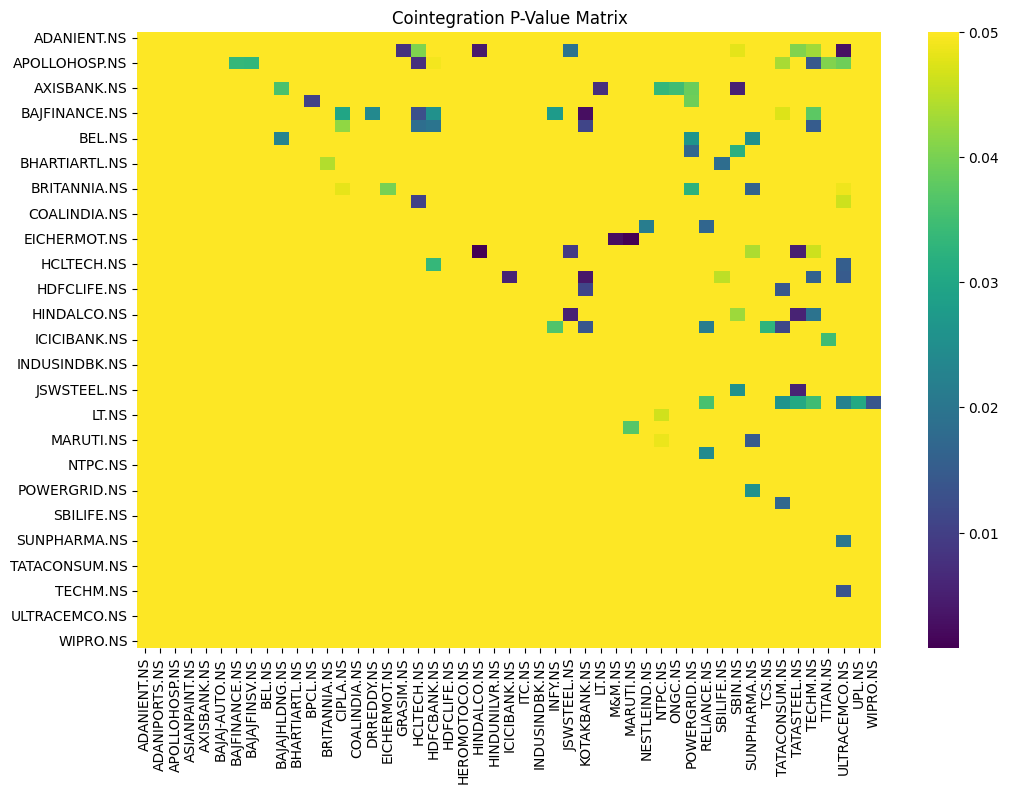

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    pvalue_df,
    cmap="viridis",
    vmax=0.05
)

plt.title("Cointegration P-Value Matrix")
plt.savefig("../reports/cointegration_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## Output

This notebook produces:

• Cointegration test results for all NIFTY 50 stock pairs  
• Ranked list of statistically significant cointegrated pairs  
• Cointegration p-value heatmap visualization  

The final dataset of significant cointegrated pairs is saved to:

data/processed/cointegrated_pairs.csv
